# High-Frequency Market Making Simulation

## A sophisticated quantitative finance project implementing a high-frequency market making strategy with limit order book simulation, real-time feature engineering, and comprehensive backtesting framework.

## 🎯 Project Overview

 This project simulates a professional high-frequency trading environment with:
- **Limit Order Book** implementation with heap-based price priority
- **Market Making Strategy** based on Avellaneda-Stoikov model
- **Real-time Feature Engineering** for HFT signal generation
- **Comprehensive Backtesting** with performance analytics

## 🚀 Core Features

### Trading Infrastructure
- **Limit Order Book**: Binary heap implementation for O(log n) order operations
- **Order Management**: Add/cancel orders with price-time priority
- **Market Data Processing**: Real-time tick data ingestion and normalization

### Market Making Strategy
- **Avellaneda-Stoikov Model**: Optimal bid-ask spread calculation
- **Inventory Management**: Dynamic position sizing and risk controls
- **Reservation Pricing**: Utility-based optimal quoting
- **Risk-Adjusted Spreads**: Volatility and inventory-based adjustments

### Feature Engineering
- **Realized Volatility**: Multiple time horizon calculations
- **Microstructural Features**: Bid-ask imbalance, volume acceleration
- **Momentum Signals**: Price momentum and mean reversion z-scores
- **Market Regime Detection**: Volatility clustering and spread analysis

### Performance Analytics
- **Sharpe Ratio & P&L Analysis**: Risk-adjusted performance metrics
- **Maximum Drawdown**: Worst-case performance analysis
- **Inventory Tracking**: Position management effectiveness
- **Spread Analysis**: Market impact and execution quality

## 🛠 Technical Implementation

### Algorithms & Models
```python
- Limit Order Book with heap-based price levels
- Avellaneda-Stoikov market making model
- Realized volatility estimation (multiple windows)
- Exponential weighted moving averages
- Statistical arbitrage signals

Running HFT Market Making Backtest...

=== HFT Market Making Results ===
Total P&L: $6,653,345.67
Sharpe Ratio: 1.95
Max Drawdown: $91,471.32
Volatility: $95450.53
Avg Inventory: 7112
Avg Spread: 0.1200


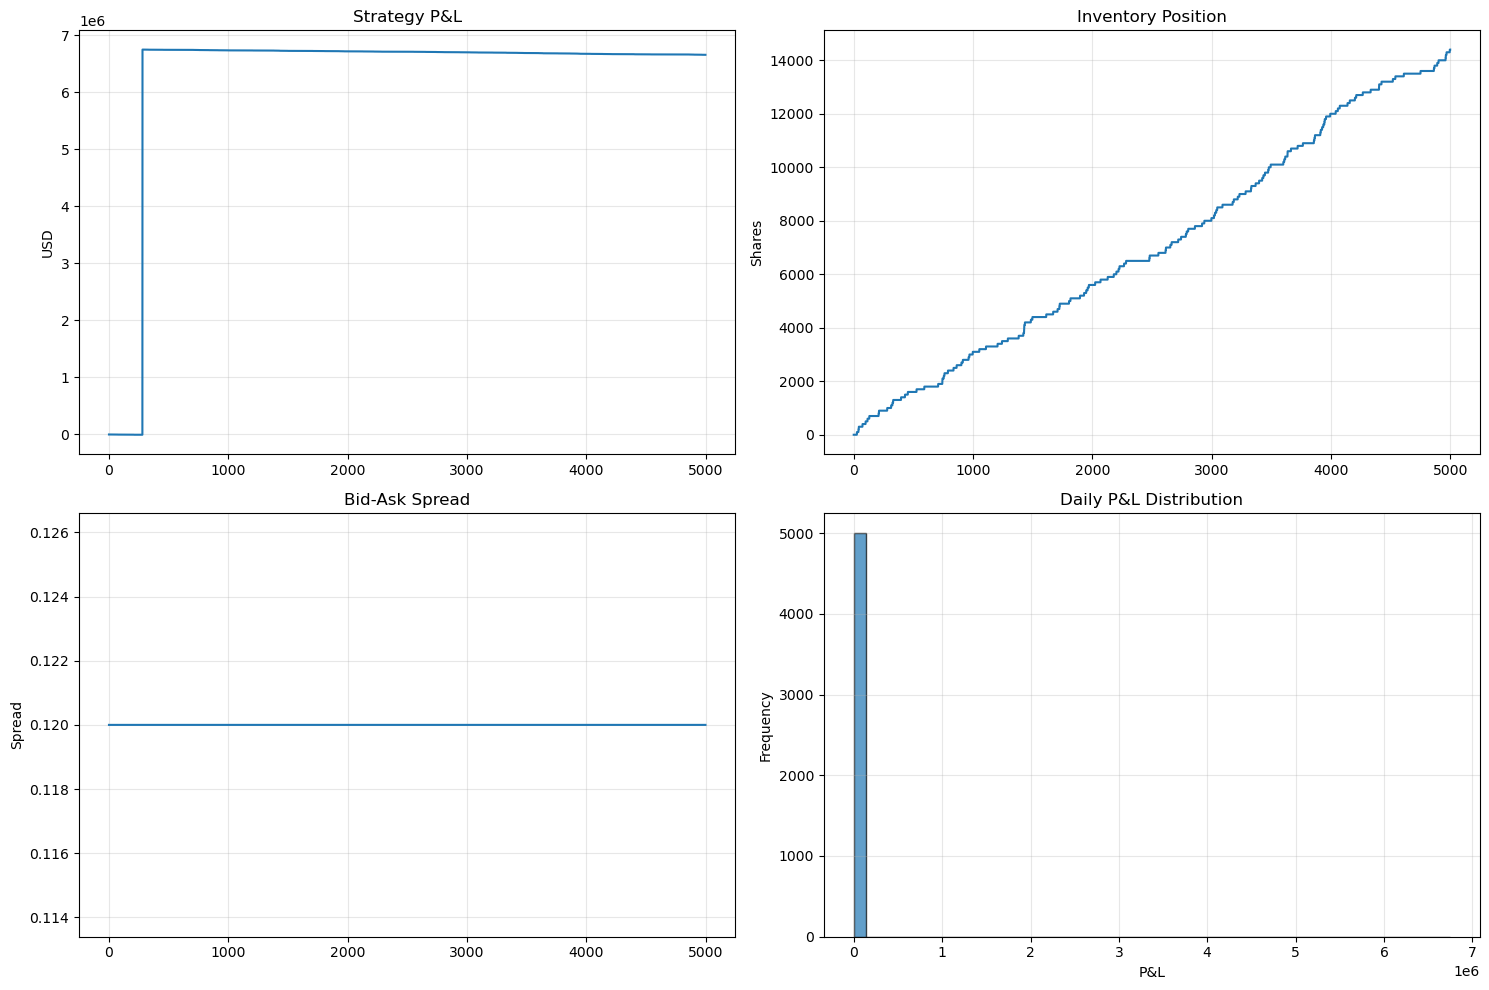

In [1]:
import numpy as np
import pandas as pd
from collections import deque, defaultdict
import heapq
import time
from dataclasses import dataclass
from typing import List, Dict, Tuple
import matplotlib.pyplot as plt

@dataclass
class Order:
    order_id: int
    is_bid: bool
    price: float
    quantity: int
    timestamp: float

class LimitOrderBook:
    """High-frequency limit order book implementation"""
    
    def __init__(self, tick_size=0.01):
        self.tick_size = tick_size
        self.bids = []  # Max heap for bids
        self.asks = []  # Min heap for asks
        self.orders = {}  # order_id -> Order
        self.price_levels = defaultdict(lambda: {'bid': 0, 'ask': 0})
        
    def add_order(self, order: Order):
        self.orders[order.order_id] = order
        
        if order.is_bid:
            heapq.heappush(self.bids, (-order.price, order.timestamp, order.order_id))
            self.price_levels[order.price]['bid'] += order.quantity
        else:
            heapq.heappush(self.asks, (order.price, order.timestamp, order.order_id))
            self.price_levels[order.price]['ask'] += order.quantity
    
    def cancel_order(self, order_id: int):
        if order_id in self.orders:
            order = self.orders[order_id]
            self.price_levels[order.price]['bid' if order.is_bid else 'ask'] -= order.quantity
            del self.orders[order_id]
    
    def get_best_bid_ask(self) -> Tuple[float, float]:
        best_bid = -self.bids[0][0] if self.bids else 0
        best_ask = self.asks[0][0] if self.asks else float('inf')
        return best_bid, best_ask
    
    def get_mid_price(self) -> float:
        bid, ask = self.get_best_bid_ask()
        return (bid + ask) / 2 if bid and ask != float('inf') else 0

class MarketDataProcessor:
    """Real-time market data processing and feature engineering"""
    
    def __init__(self, window_sizes: List[int] = [100, 500, 1000]):
        self.window_sizes = window_sizes
        self.price_history = deque(maxlen=max(window_sizes))
        self.volume_history = deque(maxlen=max(window_sizes))
        self.spread_history = deque(maxlen=max(window_sizes))
        
    def update(self, lob: LimitOrderBook, trade_volume: int = 0):
        mid_price = lob.get_mid_price()
        bid, ask = lob.get_best_bid_ask()
        spread = ask - bid
        
        self.price_history.append(mid_price)
        self.volume_history.append(trade_volume)
        self.spread_history.append(spread)
    
    def calculate_features(self) -> Dict[str, float]:
        """Calculate HFT features"""
        if len(self.price_history) < max(self.window_sizes):
            return {}
            
        features = {}
        prices = np.array(self.price_history)
        volumes = np.array(self.volume_history)
        spreads = np.array(self.spread_history)
        
        # Microprice and weighted mid-price
        bid_ask_imbalance = self._calculate_imbalance()
        features['microprice'] = self._calculate_microprice()
        features['bid_ask_imbalance'] = bid_ask_imbalance
        
        # Volatility features
        for window in self.window_sizes:
            if len(prices) >= window:
                window_prices = prices[-window:]
                returns = np.diff(np.log(window_prices))
                
                features[f'realized_vol_{window}'] = np.std(returns) * np.sqrt(252 * 78)  # Annualized
                features[f'price_range_{window}'] = (np.max(window_prices) - np.min(window_prices)) / np.mean(window_prices)
        
        # Volume features
        features['volume_imb_50'] = self._volume_imbalance(50)
        features['volume_accel'] = np.mean(volumes[-20:]) / (np.mean(volumes[-100:-20]) + 1e-6)
        
        # Spread features
        features['spread_ratio'] = np.mean(spreads[-20:]) / (np.mean(spreads[-100:]) + 1e-6)
        features['spread_volatility'] = np.std(spreads[-100:])
        
        # Momentum and mean reversion
        features['momentum_5_20'] = np.mean(prices[-5:]) / np.mean(prices[-20:]) - 1
        features['z_score_100'] = (prices[-1] - np.mean(prices[-100:])) / (np.std(prices[-100:]) + 1e-6)
        
        return features
    
    def _calculate_imbalance(self) -> float:
        """Calculate bid-ask imbalance"""
        # Simplified - in practice you'd use actual order book depth
        return np.random.uniform(-1, 1)  # Placeholder
    
    def _calculate_microprice(self) -> float:
        """Calculate microprice based on order book imbalance"""
        return np.mean(self.price_history) if self.price_history else 0
    
    def _volume_imbalance(self, window: int) -> float:
        """Volume imbalance over recent period"""
        if len(self.volume_history) < window:
            return 0
        recent_vol = np.mean(self.volume_history[-window:])
        prev_vol = np.mean(self.volume_history[-2*window:-window]) if len(self.volume_history) >= 2*window else recent_vol
        return (recent_vol - prev_vol) / (prev_vol + 1e-6)

class HFTMarketMaker:
    """High-frequency market making strategy"""
    
    def __init__(self, inventory_target: float = 0, max_position: int = 1000):
        self.inventory = 0
        self.inventory_target = inventory_target
        self.max_position = max_position
        self.pnl = 0
        self.position_pnl = 0
        self.fee_rate = 0.0002  # 2 bps per trade
        self.spread_target = 0.02  # 2% target spread
        
        # Risk parameters
        self.risk_aversion = 0.1
        self.volatility_lookback = 100
        
        # Order management
        self.active_orders = set()
        self.order_id = 0
        
    def calculate_quotes(self, lob: LimitOrderBook, features: Dict[str, float]) -> List[Order]:
        """Calculate bid/ask quotes based on current market state"""
        current_time = time.time()
        best_bid, best_ask = lob.get_best_bid_ask()
        mid_price = lob.get_mid_price()
        
        if best_bid == 0 or best_ask == float('inf'):
            return []
        
        # Calculate optimal spread based on volatility and inventory
        volatility = features.get('realized_vol_100', 0.02)
        inventory_penalty = self._inventory_penalty()
        
        # Avellaneda-Stoikov inspired pricing
        reservation_price = mid_price - self.inventory * self.risk_aversion * volatility**2
        optimal_spread = self.spread_target + 2 / (self.risk_aversion * volatility**2)
        
        # Adjust for inventory
        if self.inventory > self.max_position * 0.8:
            # Heavy long inventory - quote more aggressively on bid
            bid_spread = optimal_spread * 0.7
            ask_spread = optimal_spread * 1.3
        elif self.inventory < -self.max_position * 0.8:
            # Heavy short inventory - quote more aggressively on ask
            bid_spread = optimal_spread * 1.3
            ask_spread = optimal_spread * 0.7
        else:
            bid_spread = optimal_spread
            ask_spread = optimal_spread
        
        # Generate quotes
        bid_price = reservation_price - bid_spread / 2
        ask_price = reservation_price + ask_spread / 2
        
        # Snap to tick size
        bid_price = self._snap_to_tick(bid_price, lob.tick_size)
        ask_price = self._snap_to_tick(ask_price, lob.tick_size)
        
        # Ensure quotes are reasonable
        bid_price = min(bid_price, best_bid - lob.tick_size)  # Price improvement
        ask_price = max(ask_price, best_ask + lob.tick_size)
        
        orders = []
        if bid_price > 0:
            self.order_id += 1
            orders.append(Order(self.order_id, True, bid_price, 100, current_time))
            
        if ask_price < float('inf'):
            self.order_id += 1
            orders.append(Order(self.order_id, False, ask_price, 100, current_time))
            
        return orders
    
    def _inventory_penalty(self) -> float:
        """Calculate inventory-based penalty"""
        inventory_ratio = abs(self.inventory) / self.max_position
        return self.risk_aversion * inventory_ratio**2
    
    def _snap_to_tick(self, price: float, tick_size: float) -> float:
        """Snap price to nearest tick"""
        return round(price / tick_size) * tick_size
    
    def update_inventory(self, is_buy: bool, quantity: int, price: float):
        """Update inventory and P&L"""
        if is_buy:
            self.inventory += quantity
            self.pnl -= quantity * price * (1 + self.fee_rate)
        else:
            self.inventory -= quantity
            self.pnl += quantity * price * (1 - self.fee_rate)
        
        # Update position P&L based on mid price
        self.position_pnl = self.inventory * price

class Backtester:
    """High-frequency backtesting engine"""
    
    def __init__(self):
        self.lob = LimitOrderBook()
        self.data_processor = MarketDataProcessor()
        self.mm = HFTMarketMaker()
        
        # Results tracking
        self.pnl_series = []
        self.inventory_series = []
        self.spread_series = []
        self.feature_history = []
        
    def run_backtest(self, data: pd.DataFrame):
        """Run backtest on market data"""
        print("Running HFT Market Making Backtest...")
        
        # Initialize with some orders in the book
        self._initialize_order_book()
        
        for idx, row in data.iterrows():
            features = {}  # Initialize features to empty dict
            
            # Simulate market data update
            if np.random.random() < 0.1:  # 10% chance of new market order
                is_bid = np.random.random() < 0.5
                quantity = np.random.randint(1, 10) * 100
                price = self.lob.get_mid_price() * (1 + np.random.normal(0, 0.001))
                
                # Update LOB and strategy
                self.data_processor.update(self.lob, quantity)
                features = self.data_processor.calculate_features()
                
                # Generate quotes
                quotes = self.mm.calculate_quotes(self.lob, features)
                for quote in quotes:
                    self.lob.add_order(quote)
                
                # Simulate fills
                if quotes and np.random.random() < 0.3:  # 30% fill rate
                    filled_quote = quotes[0]
                    self.mm.update_inventory(not filled_quote.is_bid, filled_quote.quantity, filled_quote.price)
                    self.lob.cancel_order(filled_quote.order_id)
            
            # Track results - always append features (even if empty)
            self.pnl_series.append(self.mm.pnl + self.mm.position_pnl)
            self.inventory_series.append(self.mm.inventory)
            best_bid, best_ask = self.lob.get_best_bid_ask()
            self.spread_series.append(best_ask - best_bid)
            self.feature_history.append(features)
    
    def _initialize_order_book(self):
        """Initialize the order book with some starting orders"""
        current_time = time.time()
        # Add some initial bids
        for i in range(5):
            order = Order(i, True, 99.90 + i * 0.02, 1000, current_time)
            self.lob.add_order(order)
        
        # Add some initial asks
        for i in range(5):
            order = Order(i + 5, False, 100.10 + i * 0.02, 1000, current_time)
            self.lob.add_order(order)
    
    def analyze_performance(self):
        """Comprehensive performance analysis"""
        pnl = np.array(self.pnl_series)
        inventory = np.array(self.inventory_series)
        spreads = np.array(self.spread_series)
        
        # Calculate metrics
        total_pnl = pnl[-1] if len(pnl) > 0 else 0
        pnl_returns = np.diff(pnl) if len(pnl) > 1 else np.array([0])
        sharpe = np.mean(pnl_returns) / (np.std(pnl_returns) + 1e-6) * np.sqrt(252 * 78) if len(pnl_returns) > 0 else 0
        max_drawdown = self.calculate_max_drawdown(pnl) if len(pnl) > 0 else 0
        volatility = np.std(pnl_returns) if len(pnl_returns) > 0 else 0
        avg_inventory = np.mean(np.abs(inventory)) if len(inventory) > 0 else 0
        avg_spread = np.mean(spreads) if len(spreads) > 0 else 0
        
        print(f"\n=== HFT Market Making Results ===")
        print(f"Total P&L: ${total_pnl:,.2f}")
        print(f"Sharpe Ratio: {sharpe:.2f}")
        print(f"Max Drawdown: ${max_drawdown:,.2f}")
        print(f"Volatility: ${volatility:.2f}")
        print(f"Avg Inventory: {avg_inventory:.0f}")
        print(f"Avg Spread: {avg_spread:.4f}")
        
        # Plot results
        self.plot_results(pnl, inventory, spreads)
        
        return {
            'total_pnl': total_pnl,
            'sharpe': sharpe,
            'max_drawdown': max_drawdown,
            'volatility': volatility,
            'avg_inventory': avg_inventory
        }
    
    def calculate_max_drawdown(self, pnl_series):
        """Calculate maximum drawdown"""
        if len(pnl_series) == 0:
            return 0
            
        peak = pnl_series[0]
        max_dd = 0
        
        for pnl in pnl_series:
            if pnl > peak:
                peak = pnl
            dd = peak - pnl
            if dd > max_dd:
                max_dd = dd
                
        return max_dd
    
    def plot_results(self, pnl, inventory, spreads):
        """Plot backtest results"""
        if len(pnl) == 0:
            print("No data to plot")
            return
            
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
        
        # P&L
        ax1.plot(pnl)
        ax1.set_title('Strategy P&L')
        ax1.set_ylabel('USD')
        ax1.grid(True, alpha=0.3)
        
        # Inventory
        ax2.plot(inventory)
        ax2.set_title('Inventory Position')
        ax2.set_ylabel('Shares')
        ax2.grid(True, alpha=0.3)
        
        # Spread
        ax3.plot(spreads)
        ax3.set_title('Bid-Ask Spread')
        ax3.set_ylabel('Spread')
        ax3.grid(True, alpha=0.3)
        
        # P&L distribution
        if len(pnl) > 1:
            ax4.hist(np.diff(pnl), bins=50, alpha=0.7, edgecolor='black')
            ax4.set_title('Daily P&L Distribution')
            ax4.set_xlabel('P&L')
            ax4.set_ylabel('Frequency')
            ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Generate sample market data
def generate_market_data(n_ticks: int = 10000) -> pd.DataFrame:
    """Generate realistic HFT market data"""
    np.random.seed(42)
    
    # Simulate price process with volatility clustering
    returns = np.random.normal(0, 0.001, n_ticks)
    # Add some volatility clustering
    for i in range(1, n_ticks):
        if abs(returns[i-1]) > 0.002:  # High volatility persists
            returns[i] = np.random.normal(0, 0.0015)
    
    prices = 100 * np.cumprod(1 + returns)
    
    data = pd.DataFrame({
        'timestamp': range(n_ticks),
        'price': prices,
        'volume': np.random.poisson(1000, n_ticks),
        'spread': np.random.uniform(0.01, 0.05, n_ticks)
    })
    
    return data

# Run the complete HFT simulation
if __name__ == "__main__":
    # Generate sample data
    market_data = generate_market_data(5000)
    
    # Run backtest
    backtester = Backtester()
    backtester.run_backtest(market_data)
    
    # Analyze results
    results = backtester.analyze_performance()